# Mimic IV Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Fake_Datasets/MimicIV/MimicIV_fake_0.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (24230, 34)


,subject_id,hadm_id,stay_id,gender,age_at_intime,heart_rate_min,heart_rate_max,heart_rate_mean,sbp_min,sbp_max,...,creatinine_max,sodium_min,sodium_max,potassium_min,potassium_max,hemoglobin_min,hemoglobin_max,wbc_min,wbc_max,hospital_expire_flag
0,1.281637e+07,2.224459e+07,3.140192e+07,M,44,60.781609,98.997528,85.573959,115.026207,170.337326,...,0.765372,143.056488,139.627686,3.472111,3.461715,12.767086,15.324256,2.653108,6.877002,0
1,1.088993e+07,2.951322e+07,3.419136e+07,F,47,51.376675,64.196823,66.707977,101.701881,153.501373,...,0.761308,137.407028,140.716232,4.051133,4.202180,7.896755,13.474009,5.745215,10.005170,0
2,1.331510e+07,2.705617e+07,3.568733e+07,M,88,60.748844,91.583511,74.460114,70.597412,140.216309,...,1.465819,121.220718,135.515640,2.329532,2.853708,7.549850,8.346193,7.098319,2.959111,0
3,1.749231e+07,2.156061e+07,3.131189e+07,M,24,43.338562,78.619492,65.377342,43.402775,137.231079,...,2.188363,153.048294,152.213562,3.485275,6.498617,13.283210,15.932930,5.232524,9.151387,0
4,1.448365e+07,2.803929e+07,3.683837e+07,F,62,70.694221,111.598495,79.066162,116.788605,148.097565,...,1.186170,137.881195,134.373871,4.320086,4.108965,6.105699,8.134489,12.064657,13.694910,0


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24230 entries, 0 to 24229
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            24230 non-null  float64
 1   hadm_id               24230 non-null  float64
 2   stay_id               24230 non-null  float64
 3   gender                24230 non-null  object 
 4   age_at_intime         24230 non-null  int64  
 5   heart_rate_min        24224 non-null  float64
 6   heart_rate_max        24227 non-null  float64
 7   heart_rate_mean       24123 non-null  float64
 8   sbp_min               24104 non-null  float64
 9   sbp_max               24226 non-null  float64
 10  sbp_mean              24227 non-null  float64
 11  dbp_min               24044 non-null  float64
 12  dbp_max               24127 non-null  float64
 13  dbp_mean              24125 non-null  float64
 14  resp_rate_min         24102 non-null  float64
 15  resp_rate_max      

## 3. Missing Values

In [3]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 0.9315141657158117


,missing_count,missing_percent
sodium_min,618,2.550557
hemoglobin_min,586,2.418489
potassium_min,582,2.401981
wbc_max,535,2.208007
wbc_min,519,2.141973
sodium_max,504,2.080066
creatinine_min,499,2.059430
potassium_max,497,2.051176
hemoglobin_max,480,1.981015
temperature_max,425,1.754024


## 4. Missing Values Plot

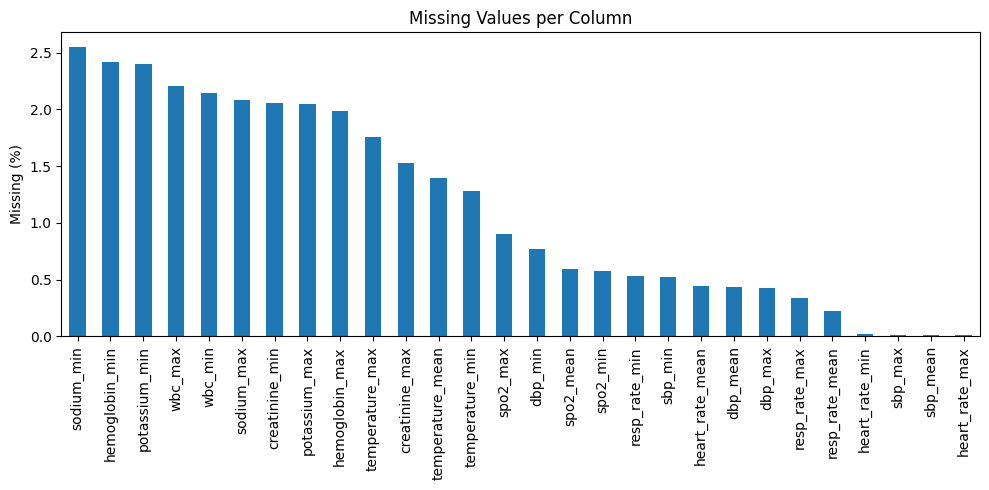

In [4]:
plt.figure(figsize=(10,5))
missing_pct[missing_pct > 0].plot(kind='bar')
plt.ylabel('Missing (%)')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [5]:
df_filtered = df[df.notna().sum(axis=1) >= 10]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered.shape[0])

x = 30  # threshold in percent

missing_pct = df_filtered.isna().mean() * 100
df_filtered2 = df_filtered.loc[:, missing_pct <= x]

removed = set(df_filtered.columns) - set(df_filtered2.columns)
print("Dropped columns:", removed)

print("Filtered2 shape:", df_filtered2.shape)


Original shape: (24230, 34)
Filtered shape: (24230, 34)
Rows removed: 0
Dropped columns: set()
Filtered2 shape: (24230, 34)


## 5. Numeric Distributions

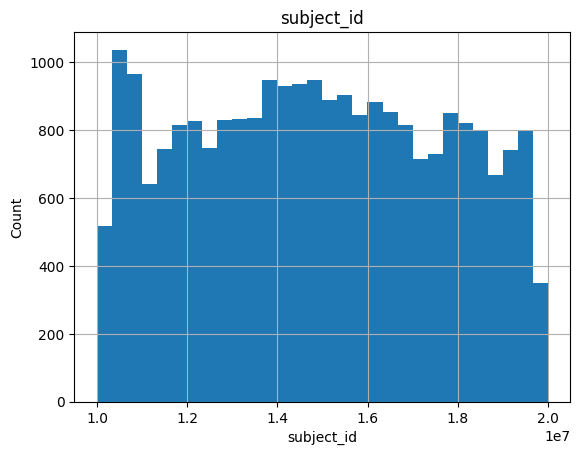

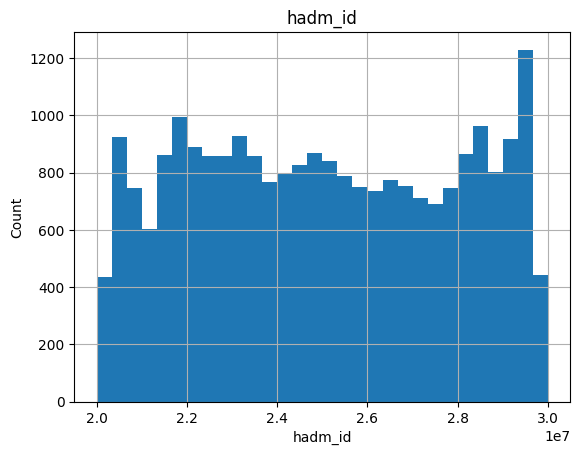

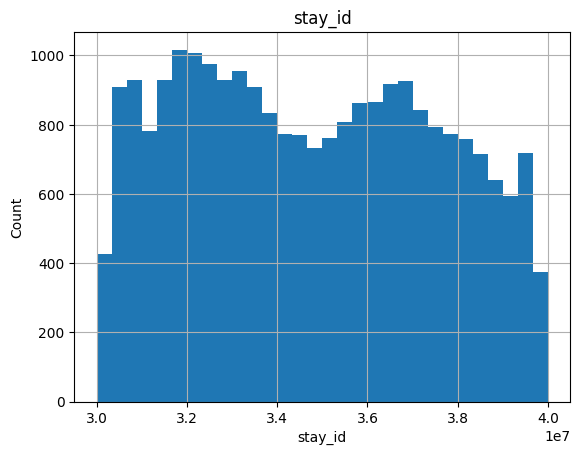

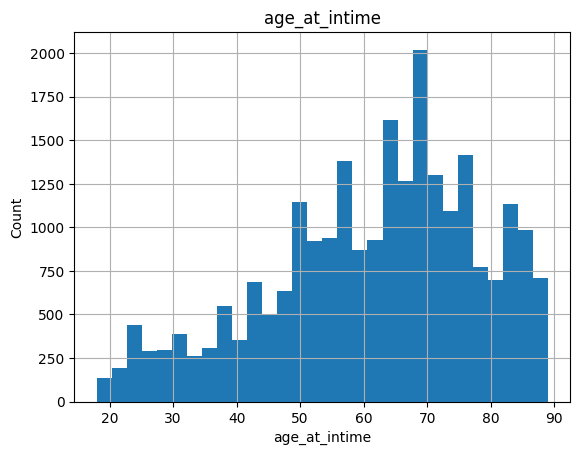

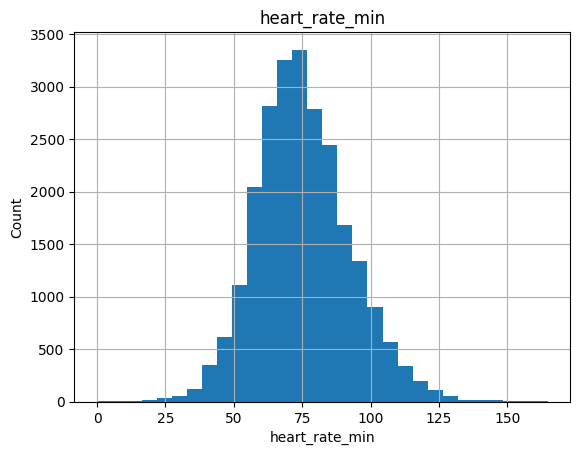

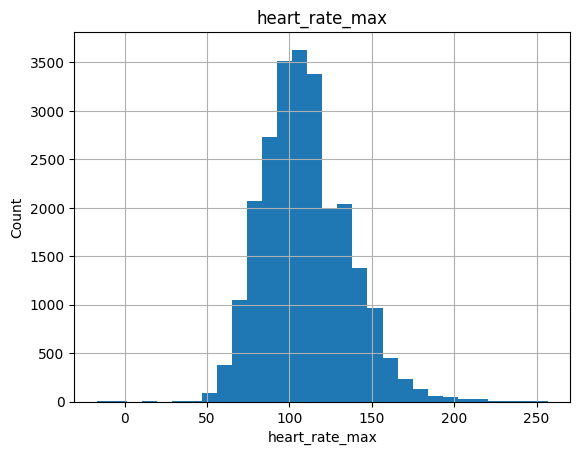

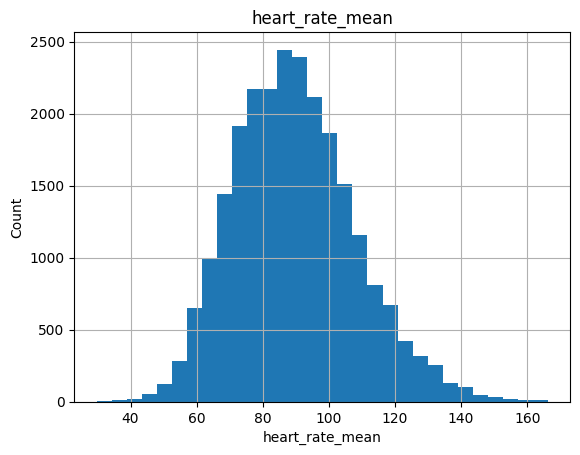

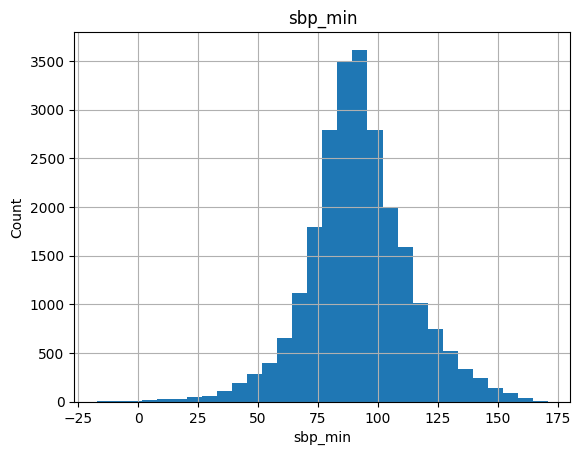

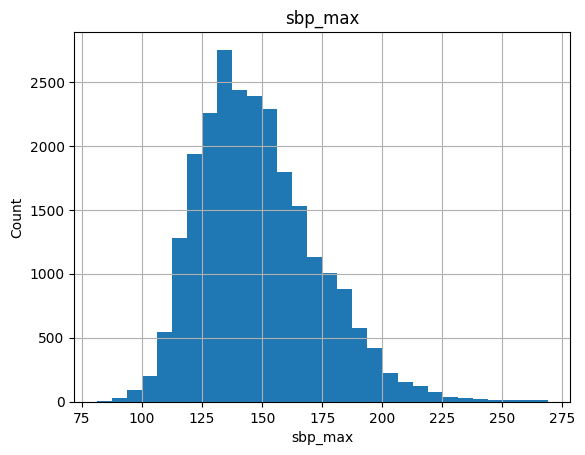

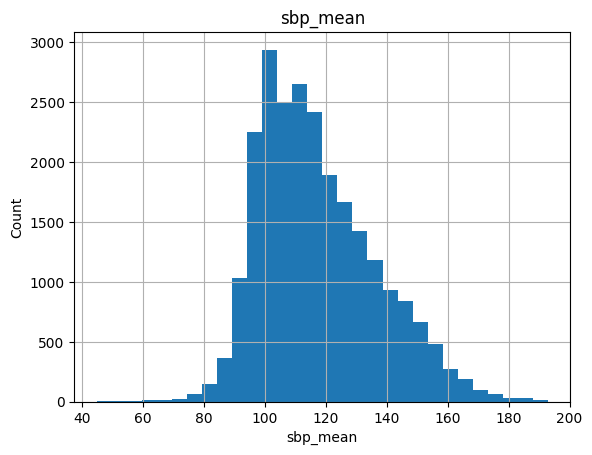

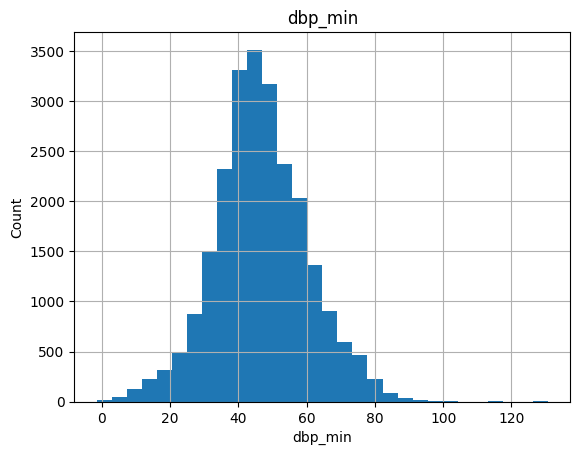

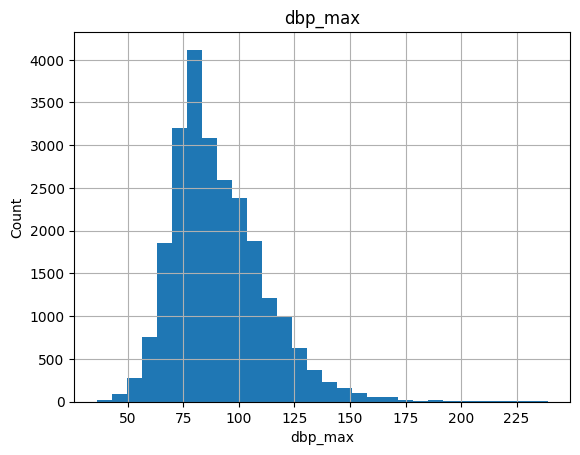

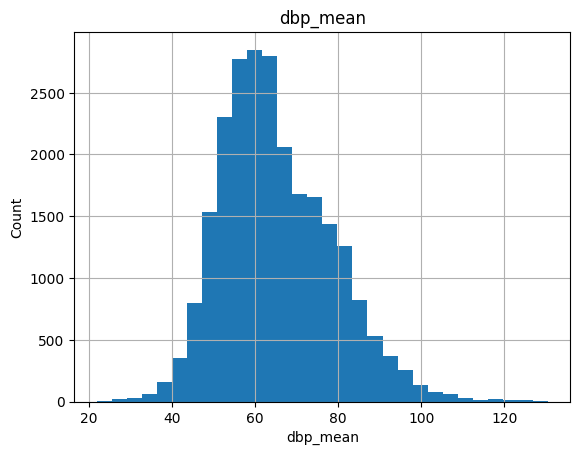

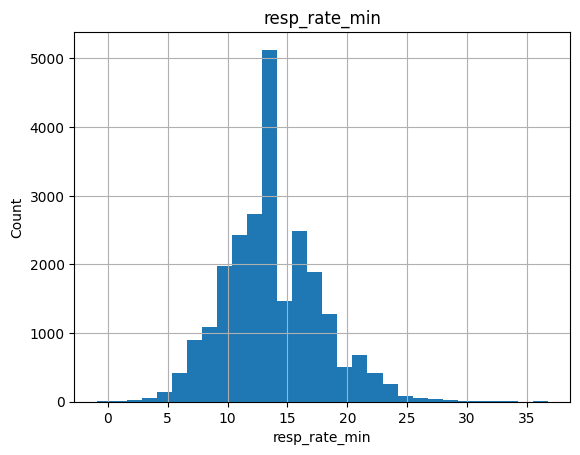

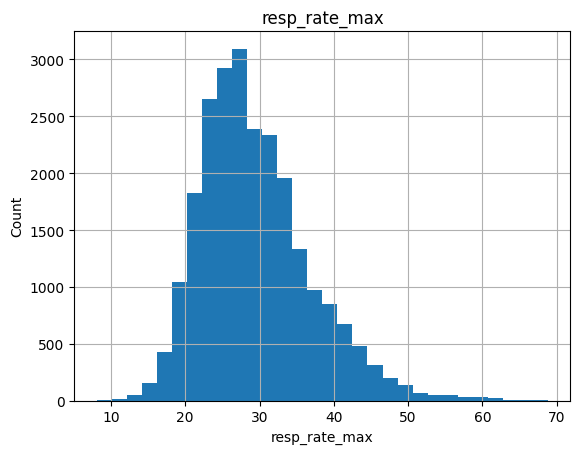

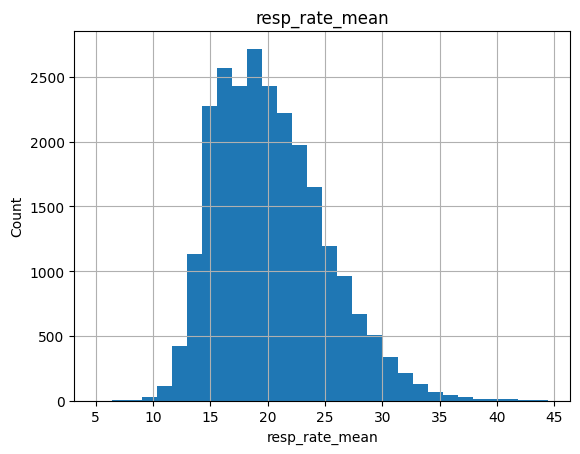

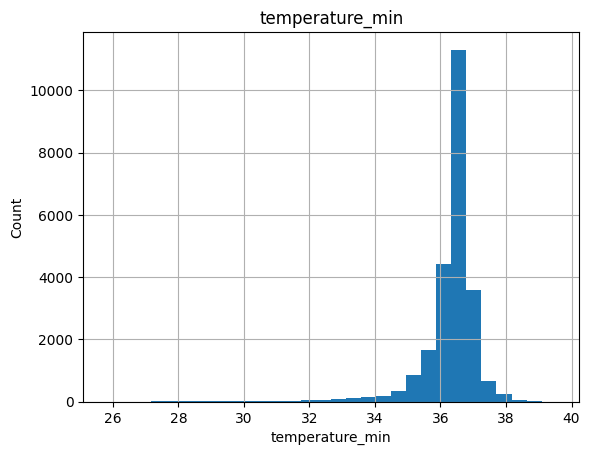

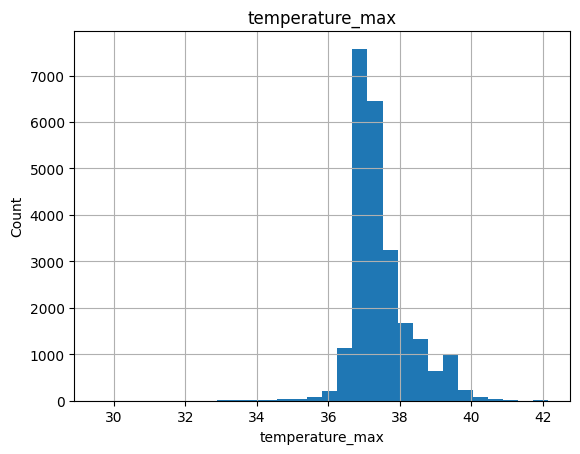

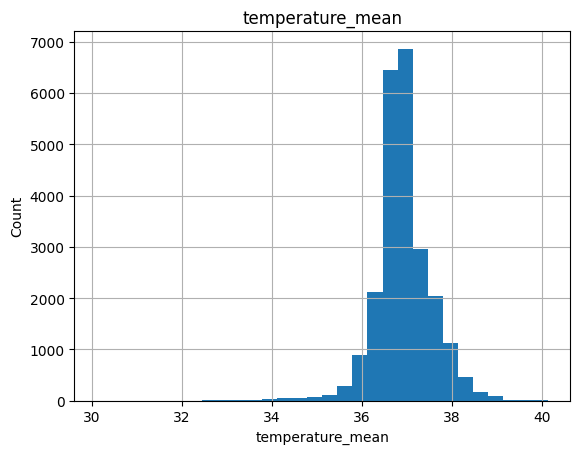

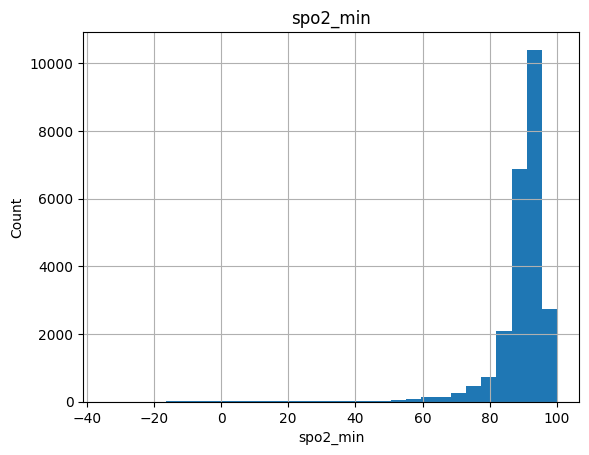

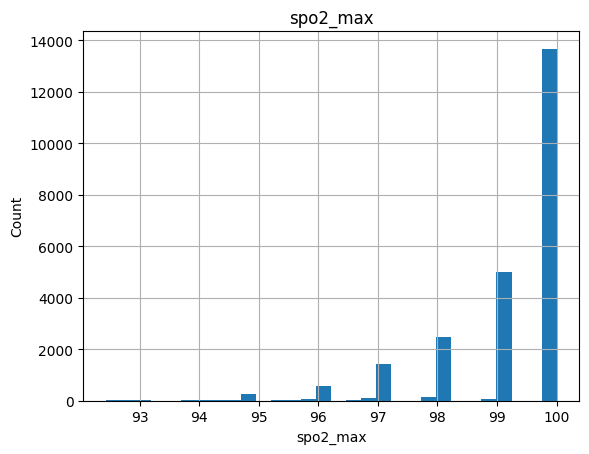

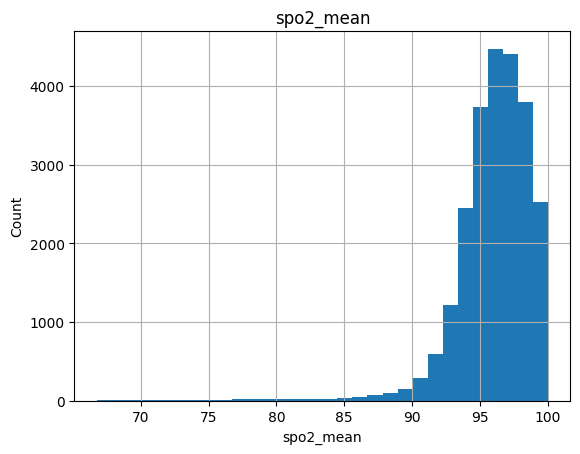

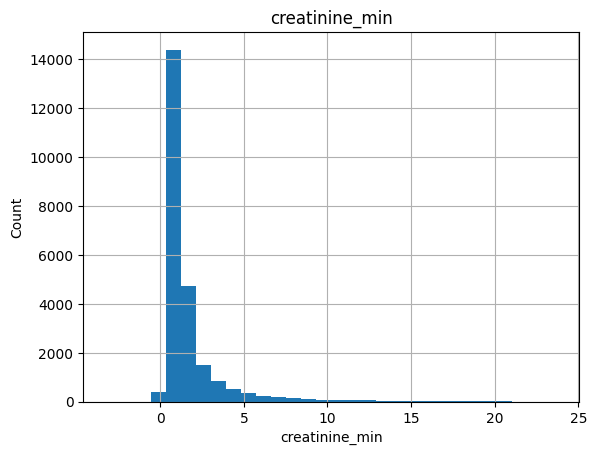

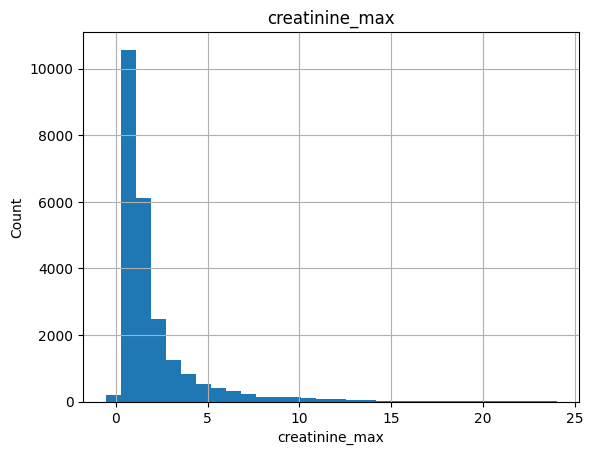

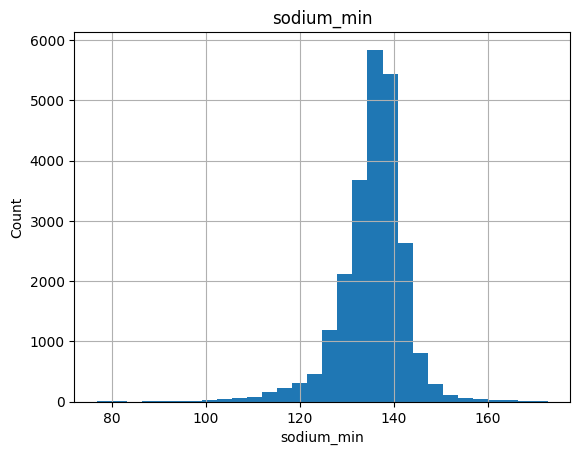

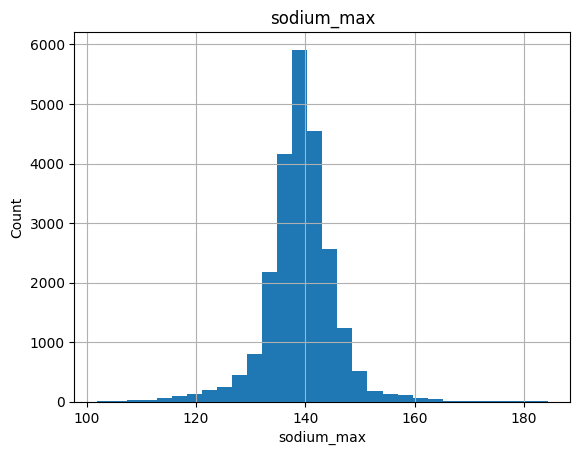

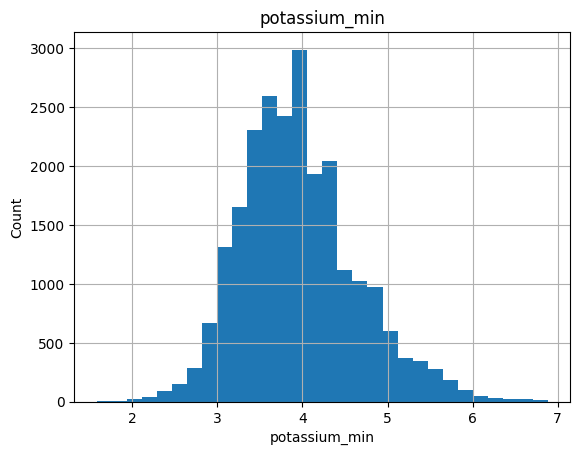

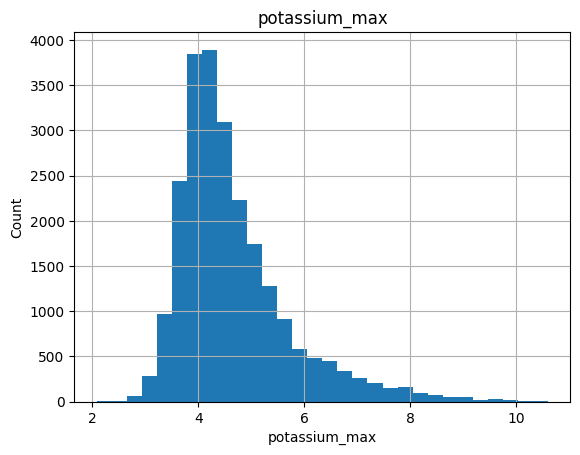

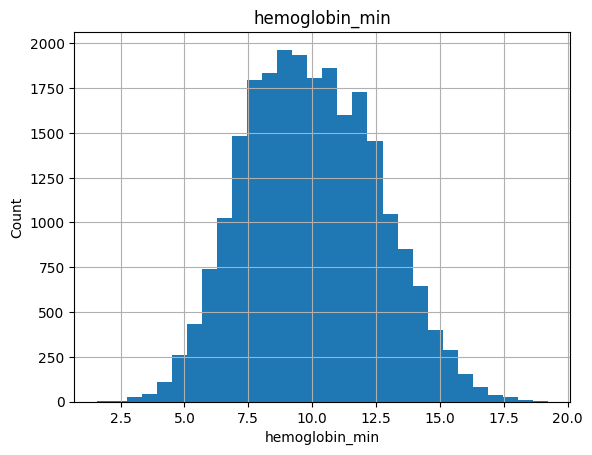

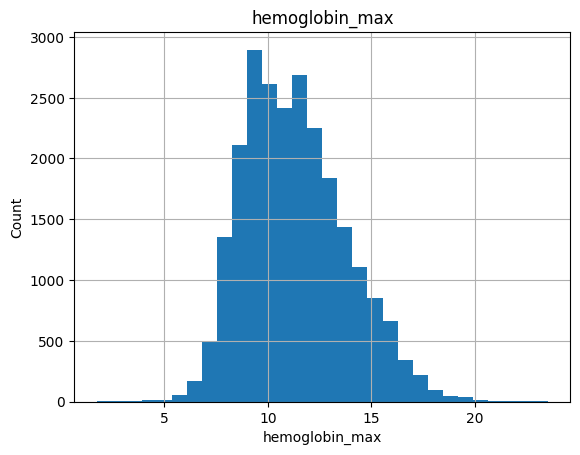

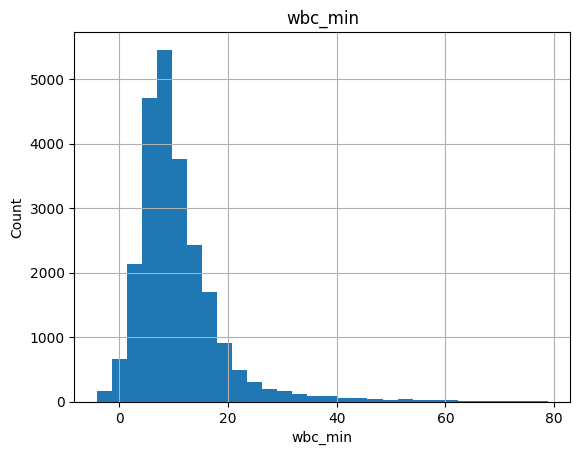

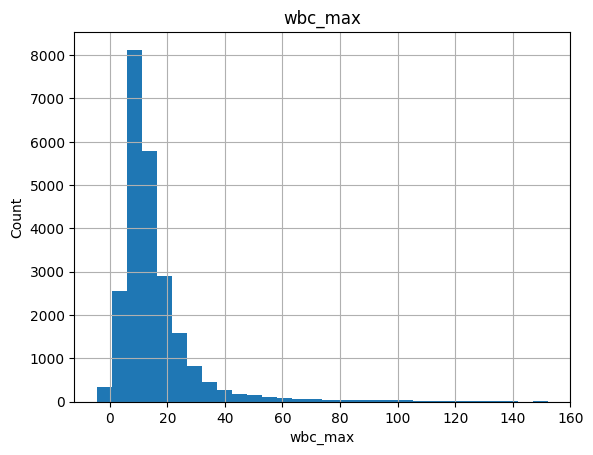

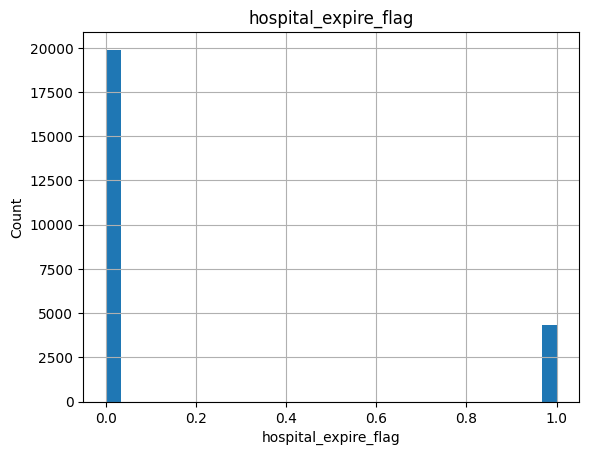

In [6]:
num_cols = df_filtered2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df_filtered2[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

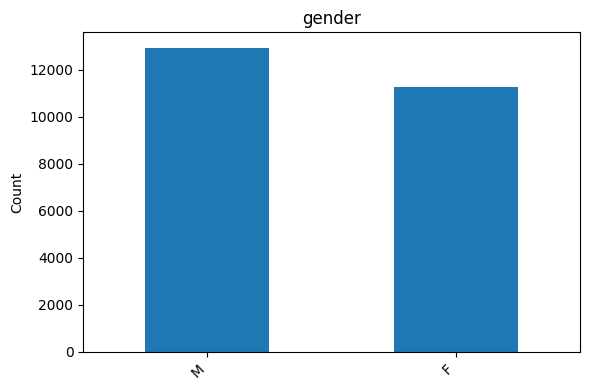

In [7]:
cat_cols = df_filtered2.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df_filtered2[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training